In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%config InlineBackend.figure_format = 'retina'

In [2]:
RANDOM_SEED = 666

In [3]:
df = pd.read_csv("data/airline_satisfaction/train.csv",index_col=0)
df.head(5)

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [22]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer 
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression

### SimpleImputer: Used to fill in missing data in a dataset with a specified strategy, such as mean, median, or mode, we use mean in our dataset

### OneHotEncoder: Converts categorical features into a format that can be provided to machine learning algorithms by creating binary columns for each category

### OrdinalEncoder: Transforms categorical features into integer values that represent the ordinal relationship between categories, preserving their order. In our dataset for low speed we encode it as '0' for high speed we encode it '1'

In [5]:
# Drop 'id' column
if 'id' in df.columns:
    df = df.drop(columns=['id'])

In [6]:
df.head(5)

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [11]:
df.isnull().sum() ##Arrival Delay in Minutes has 310 missing values

Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             310
satisfaction                           0
dtype: int64

In [67]:
#Separate features and target
X = df.drop(columns = ["satisfaction"])
y = df["satisfaction"].map({'satisfied': 1, 'neutral or dissatisfied': 0})  # Convert to binary

In [68]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [69]:
# Identify numerical and categorical features
num_features = X_train.select_dtypes(include=['int','float64']).columns.tolist()
cat_features = X_train.select_dtypes(include=['object']).columns.tolist()

In [70]:
cat_features

['Gender', 'Customer Type', 'Type of Travel', 'Class']

### We'll create a pipeline that includes:

#### -Scaling numerical features.

#### -One-hot-encoding categorical features.

#### -Handling missing data.

#### -Fitting a Logistic Regression model.

In [71]:
#preprocessing for numerical features

numerical_transformer = Pipeline( 
    steps =[
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
    ]
)

In [72]:
#preprocessing for categorical features
categorical_transformer = Pipeline(
    steps =[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))   
    ]
)

In [73]:
#Combine preprocessing steps
preprocessor_transformer = ColumnTransformer(
    transformers=[
    ('numerical',numerical_transformer,num_features),
    ('categorical',categorical_transformer,cat_features)
    ]
)

In [74]:
#Create the full pipeline
pipeline = Pipeline(steps=[
    ('pre-processor',preprocessor_transformer),
    ('classifier',LogisticRegression(max_iter=1000))
    ]
)

### Define the Grid Search Parameters

#### We'll search across different values for the following hyperparameters:

##### C: Inverse of regularization strength.

##### penalty: Type of regularization (L1 or L2).

##### solver: Algorithm to use in the optimization problem.

In [75]:
#Define the parameter grid
param_grid = [
    {
        'classifier__penalty': ['l1'],
        'classifier__C': [0.01, 1, 100],
        'classifier__solver': ['liblinear', 'saga'],
        'classifier__max_iter': [1000]
    },
    {
        'classifier__penalty': ['l2'],
        'classifier__C': [0.01, 1, 100],
        'classifier__solver': ['lbfgs', 'sag', 'saga'],
        'classifier__max_iter': [1000]
    }
]

#### Perform Grid Search with Cross-Validation

In [48]:
# Setup grid search CV
grid_search = GridSearchCV(pipeline,param_grid,cv=5,scoring='roc_auc')

In [49]:
# fit the model
grid_search.fit(X_train,y_train)

/home/akshayghime/.local/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/akshayghime/.local/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('pre-processor',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'Flight '
                                                                          'Distance',
                                                                          'Inflight '
                                                                          'wifi '
                                                                          'service',
                                                                          'Departure/Arrival '
                                                                          'time '
                                                                          'convenient',
                                                                          'Ease '
                                                                          'of '
                                                                          'Online '
                                                                          'booking',
                                                                          'Gate '
                                                                          'location',
                                                                          'Food '
                                                                          'and '
                                                                          'drink'...
                                                                          'Class'])])),
                                       ('classifier',
                                        LogisticRegression(max_iter=1000))]),
             param_grid=[{'classifier__C': [0.01, 1, 100],
                          'classifier__max_iter': [1000],
                          'classifier__penalty': ['l1'],
                          'classifier__solver': ['liblinear', 'saga']},
                         {'classifier__C': [0.01, 1, 100],
                          'classifier__max_iter': [1000],
                          'classifier__penalty': ['l2'],
                          'classifier__solver': ['lbfgs', 'sag', 'saga']}],
             scoring='roc_auc')

In [76]:
#best parameters LogisticRegression(C=0.01, max_iter=1000, penalty='l1', solver='saga')
# Print the best parameters
print("Best parameters found: ", grid_search.best_params_)

Best parameters found:  {'classifier__C': 0.01, 'classifier__max_iter': 1000, 'classifier__penalty': 'l1', 'classifier__solver': 'saga'}


In [77]:
#Predict on the test set
y_pred_proba = grid_search.predict_proba(X_test)[:,1]

In [78]:
from sklearn.metrics import roc_auc_score,roc_curve,auc
# Calculate the ROC AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC Score on Test Set: {roc_auc:.4f}")

ROC AUC Score on Test Set: 0.9276


In [79]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

In [80]:
# Compute ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)  # Compute AUC

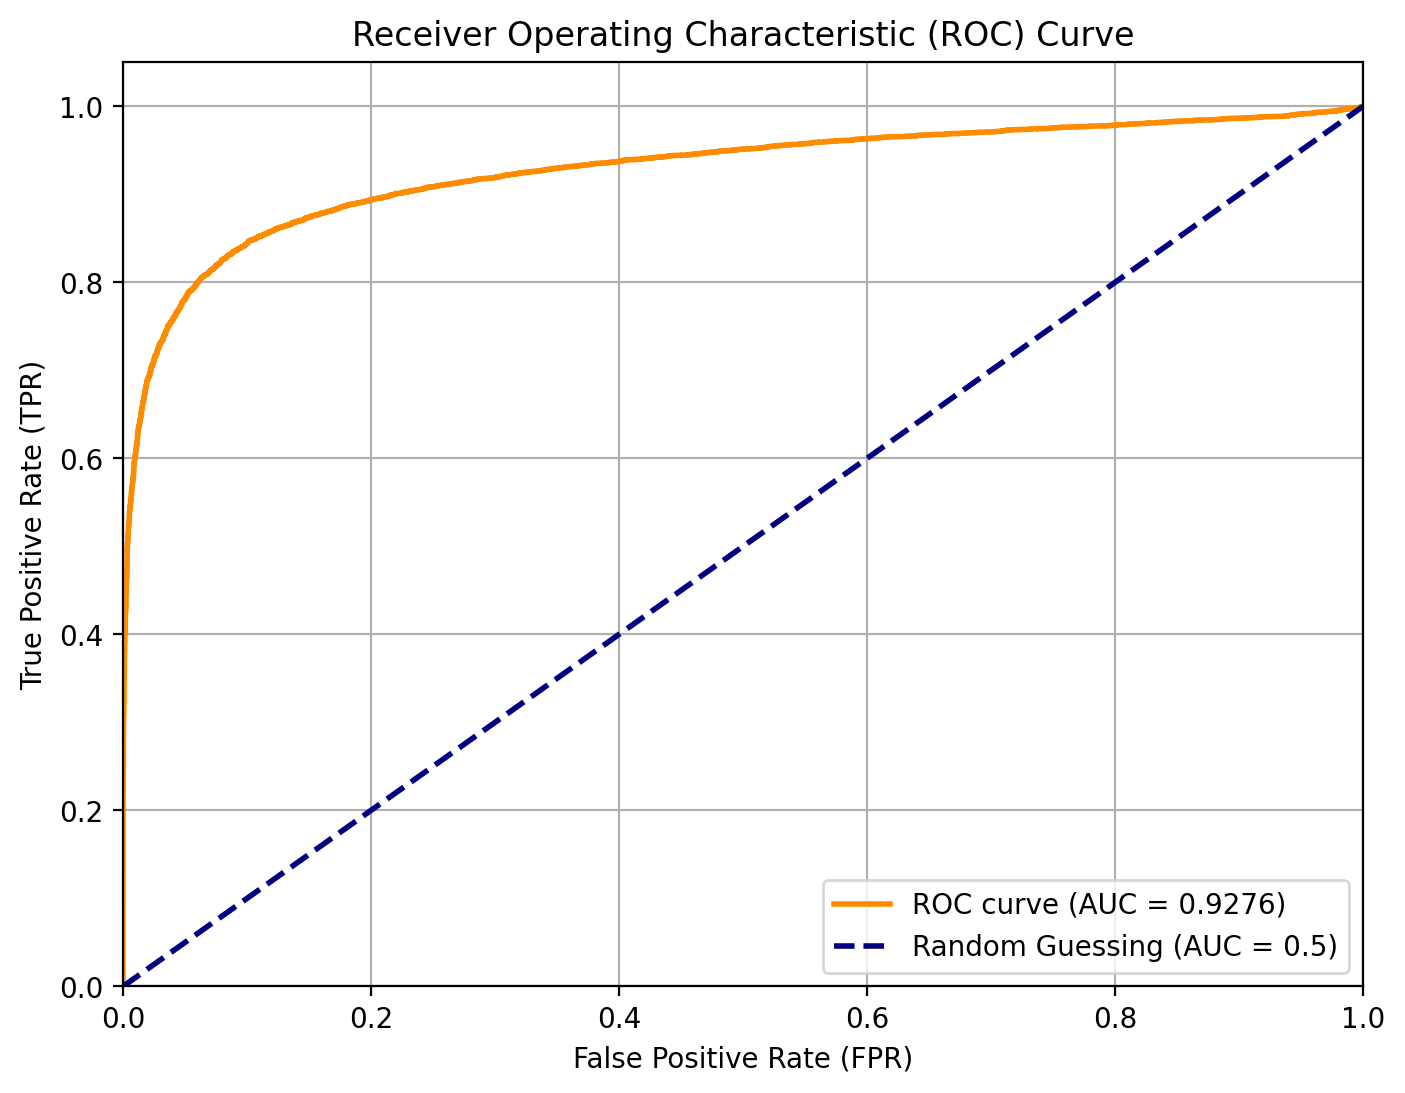

In [81]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()